In [ ]:
from google.colab import drive
drive.mount('/content/Drive')

Mounted at /content/Drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/Drive/MyDrive/Colab Notebooks/Housing.csv')

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
print(df.columns)
print(df.info())
print(df.isnull().sum())

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null 

In [ ]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [ ]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1,1)
).ravel()

In [ ]:
model = SGDRegressor(
    max_iter=1,
    tol=None,
    warm_start=True,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

In [ ]:
epochs = 100
loss_history = []

for epoch in range(epochs):

    model.partial_fit(X_train_scaled, y_train_scaled)

    prediction = model.predict(X_train_scaled)

    loss = mean_squared_error(
        y_train_scaled,
        prediction
    )

    loss_history.append(loss)

print("Training Complete")

Training Complete


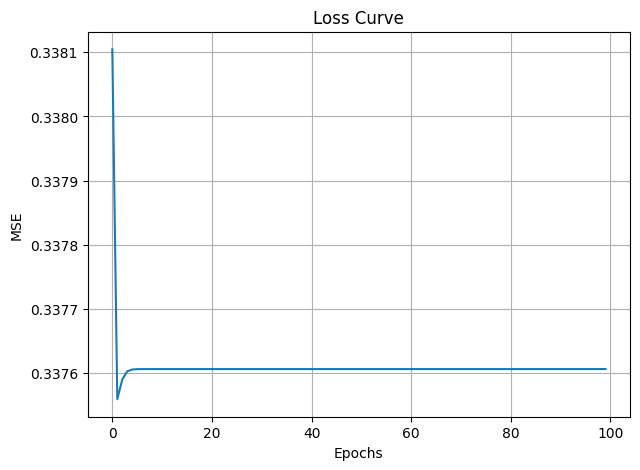

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(loss_history)

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")

plt.grid(True)
plt.show()

In [ ]:
y_pred_scaled = model.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).ravel()

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

MAE : 958417.4279910502
MSE : 1724562310445.1145
R2  : 0.6588112883212708


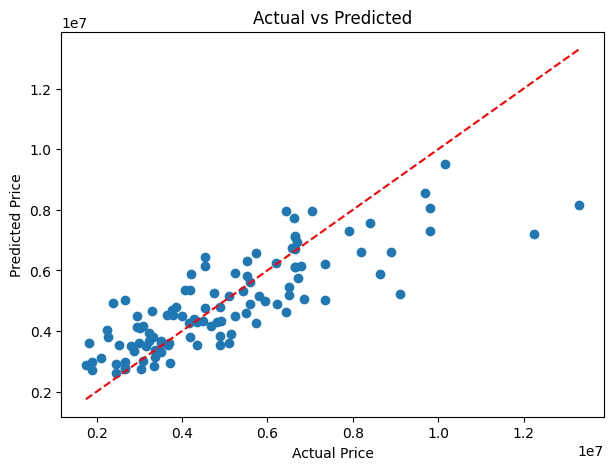

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred.round(0)
})

print(comparison.head(10))

    Actual  Predicted
0  4060000  5338513.0
1  6650000  7125112.0
2  3710000  2941247.0
3  6440000  4629487.0
4  2800000  3490989.0
5  4900000  3545379.0
6  5250000  5906917.0
7  4543000  6146773.0
8  2450000  2603641.0
9  3353000  2835224.0
